Linear Regression Results (California Housing - MedInc):
Mean Squared Error: 0.7091157771765549
R² Score: 0.45885918903846656


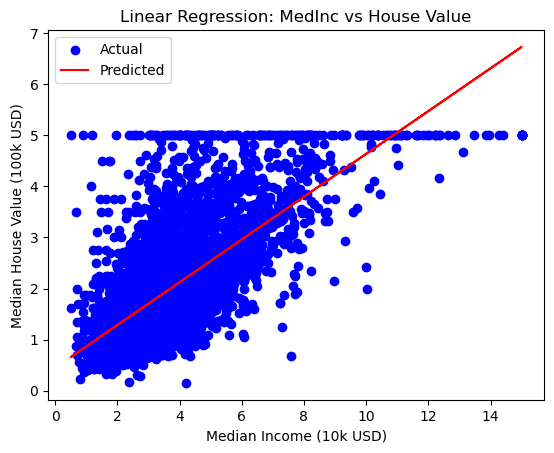


Polynomial Regression Results (Auto MPG - Horsepower):
Mean Squared Error: 18.416967796018056
R² Score: 0.639170114701326


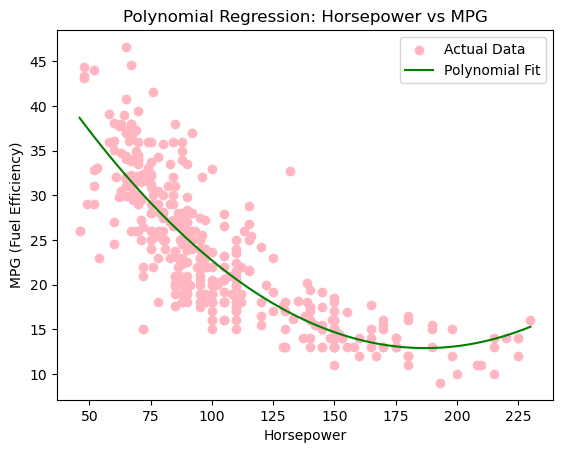

In [10]:
# Linear Regression using California Housing Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Use 'MedInc' (Median Income) to predict house value for simplicity
X = X[['MedInc']]  # simple regression with 1 feature

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Linear Regression Results (California Housing - MedInc):")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Plot
plt.scatter(X_test, y_test, color='blue', label="Actual")
plt.plot(X_test, y_pred, color='red', label="Predicted")
plt.xlabel("Median Income (10k USD)")
plt.ylabel("Median House Value (100k USD)")
plt.title("Linear Regression: MedInc vs House Value")
plt.legend()
plt.show()


import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

df = sns.load_dataset('mpg').dropna()
X = df[['horsepower']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)

y_poly_pred = poly_model.predict(X_test)
print("\nPolynomial Regression Results (Auto MPG - Horsepower):")
print("Mean Squared Error:", mean_squared_error(y_test, y_poly_pred))
print("R² Score:", r2_score(y_test, y_poly_pred))


X_plot = pd.DataFrame(np.linspace(X.min().values, X.max().values, 100), columns=["horsepower"])
y_plot = poly_model.predict(X_plot)

plt.scatter(X, y, color='lightpink', label='Actual Data')
plt.plot(X_plot, y_plot, color='green', label='Polynomial Fit')
plt.xlabel("Horsepower")
plt.ylabel("MPG (Fuel Efficiency)")
plt.title("Polynomial Regression: Horsepower vs MPG")
plt.legend()
plt.show()



